In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('credit_card_data.csv')
df.head()

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [3]:
df.shape

(10000, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [5]:
df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [6]:
df['merchant_category'].value_counts()

merchant_category
Food           2093
Clothing       2050
Travel         1990
Grocery        1944
Electronics    1923
Name: count, dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['merchant_category'] = le.fit_transform(df['merchant_category'])

df['merchant_category'].value_counts()

merchant_category
2    2093
0    2050
4    1990
3    1944
1    1923
Name: count, dtype: int64

In [8]:
df = df.drop('transaction_id', axis=1)
df.head()

,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,84.47,22,1,0,0,66,3,40,0
1,541.82,3,4,1,0,87,1,64,0
2,237.01,17,3,0,0,49,1,61,0
3,164.33,4,3,0,1,72,3,34,0
4,30.53,15,2,0,0,79,0,44,0


In [9]:
X = df.drop('is_fraud', axis=1)
y = df['is_fraud']

print(X.shape)
print(y.shape)

(10000, 8)
(10000,)


In [10]:
features = ["amount", "transaction_hour", "merchant_category", "foreign_transaction", "location_mismatch", "device_trust_score", "velocity_last_24h", "cardholder_age"]
X = df[features]
y = df.is_fraud

print(X.shape)
print(y.shape)

(10000, 8)
(10000,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)

(8000, 8)
(2000, 8)


In [12]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       1.00      0.61      0.76        31

    accuracy                           0.99      2000
   macro avg       1.00      0.81      0.88      2000
weighted avg       0.99      0.99      0.99      2000



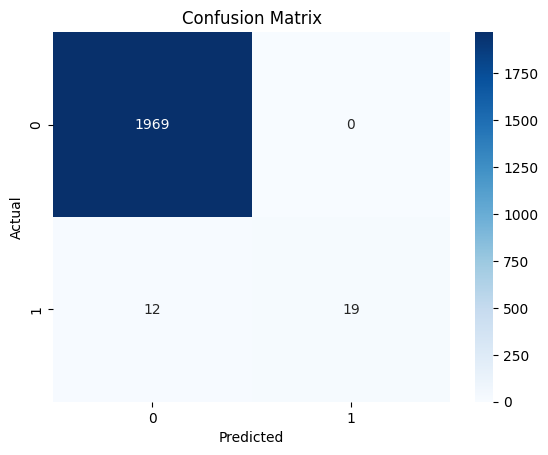

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [15]:
pip install imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\celin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

is_fraud
0    7880
1    7880
Name: count, dtype: int64


In [17]:
model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = model_smote.predict(X_test)

print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      1969
           1       0.26      0.61      0.36        31

    accuracy                           0.97      2000
   macro avg       0.63      0.79      0.67      2000
weighted avg       0.98      0.97      0.97      2000



In [18]:
model_weighted = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_weighted.fit(X_train, y_train)

y_pred_weighted = model_weighted.predict(X_test)

print(classification_report(y_test, y_pred_weighted))

              precision    recall  f1-score   support

           0       0.99      1.00      1.00      1969
           1       1.00      0.55      0.71        31

    accuracy                           0.99      2000
   macro avg       1.00      0.77      0.85      2000
weighted avg       0.99      0.99      0.99      2000

